In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import numpy as np
import shutil
import os

In [4]:
from dataset_loader import *

/Users/michaelbehrens/micromamba/envs/cs135_25f_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using: Gemini_Generated_Image_f1ghbxf1ghbxf1gh_paper_Final Project-35_P6_R0_A06


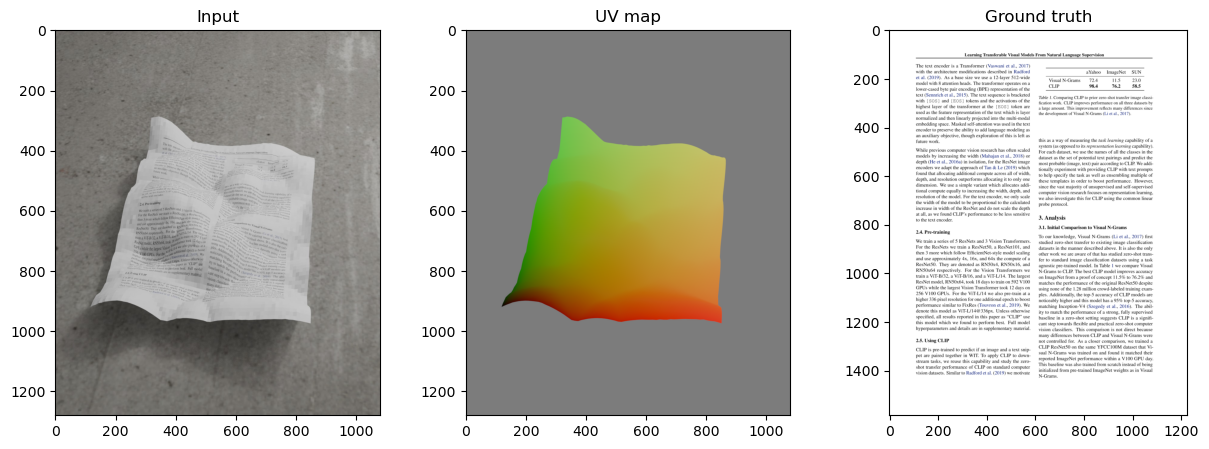

UV shape: (1280, 1080, 3), dtype: uint8
Background: [124 124 124]
Center: [174 160  40]


In [24]:
# get any filename from the dataset
rgb_dir = 'renders/synthetic_data_pitch_sweep/rgb'
filename = os.listdir(rgb_dir)[0].replace('.jpg', '')
print(f"Using: {filename}")

rgb = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/rgb/{filename}.jpg').convert('RGB'))
uv = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/uv/{filename}.png').convert('RGB'))
gt = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/ground_truth/{filename}.png').convert('RGB'))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb); axes[0].set_title('Input')
axes[1].imshow(uv);  axes[1].set_title('UV map')
axes[2].imshow(gt);  axes[2].set_title('Ground truth')
plt.show()

print(f"UV shape: {uv.shape}, dtype: {uv.dtype}")
print(f"Background: {uv[0,0]}")
print(f"Center: {uv[640, 540]}")

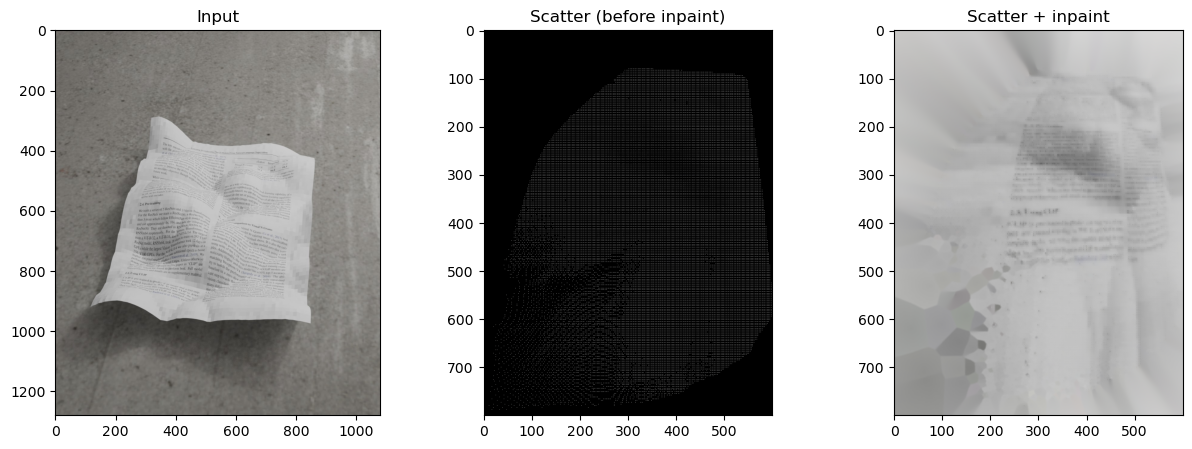

In [34]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

rgb = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/rgb/{filename}.jpg').convert('RGB'))
uv = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/uv/{filename}.png').convert('RGB'))

# out_h, out_w = rgb.shape[0], rgb.shape[1]
out_h, out_w = 800, 600  # portrait document

bg = np.array([124, 124, 124])
diff = np.abs(uv.astype(int) - bg).max(axis=2)
doc_mask = diff > 30

u = uv[:,:,0].astype(np.float32) / 219.0
v = 1.0 - uv[:,:,1].astype(np.float32) / 219.0  # flip y

# out_x = (u * (out_w - 1)).astype(int).clip(0, out_w-1)
# out_y = (v * (out_h - 1)).astype(int).clip(0, out_h-1)
out_x = (u * (out_w - 1)).astype(int).clip(0, out_w-1)
out_y = (v * (out_h - 1)).astype(int).clip(0, out_h-1)

output = np.zeros((out_h, out_w, 3), dtype=np.float32)
counts = np.zeros((out_h, out_w), dtype=np.float32)

ys = out_y[doc_mask]
xs = out_x[doc_mask]
pixels = rgb[doc_mask].astype(np.float32) / 255.0

np.add.at(output, (ys, xs), pixels)
np.add.at(counts, (ys, xs), 1)

counts = np.maximum(counts, 1)
output = output / counts[:,:,None]

# inpaint holes
output_uint8 = (output * 255).astype(np.uint8)
hole_mask = (counts == 1).astype(np.uint8) * 255
result = cv2.inpaint(output_uint8, hole_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title('Input')
axes[1].imshow(output_uint8)
axes[1].set_title('Scatter (before inpaint)')
axes[2].imshow(result)
axes[2].set_title('Scatter + inpaint')
plt.show()

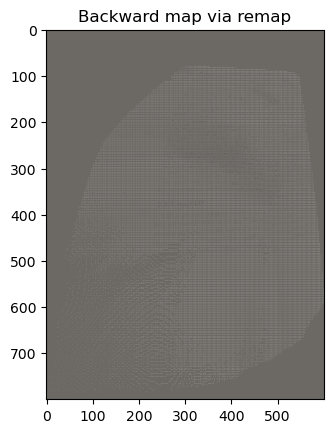

In [35]:
# forward UV says: input pixel (x,y) → output location (u,v)
# to invert: for each output pixel, find which input pixel maps there
# build a backward map by scattering input coordinates to output locations

in_h, in_w = rgb.shape[:2]

# input pixel coordinates
in_ys, in_xs = np.mgrid[0:in_h, 0:in_w]
in_y_norm = in_ys.astype(np.float32) / (in_h - 1)  # [0,1]
in_x_norm = in_xs.astype(np.float32) / (in_w - 1)  # [0,1]

# scatter input coords to output locations
back_x = np.zeros((out_h, out_w), dtype=np.float32)
back_y = np.zeros((out_h, out_w), dtype=np.float32)
counts = np.zeros((out_h, out_w), dtype=np.float32)

np.add.at(back_x, (out_y[doc_mask], out_x[doc_mask]), in_x_norm[doc_mask])
np.add.at(back_y, (out_y[doc_mask], out_x[doc_mask]), in_y_norm[doc_mask])
np.add.at(counts,  (out_y[doc_mask], out_x[doc_mask]), 1)

counts = np.maximum(counts, 1)
back_x = back_x / counts
back_y = back_y / counts

# now use cv2.remap with the backward map
map_x = (back_x * (in_w - 1)).astype(np.float32)
map_y = (back_y * (in_h - 1)).astype(np.float32)

result = cv2.remap(rgb, map_x, map_y, interpolation=cv2.INTER_LINEAR)

plt.imshow(result)
plt.title('Backward map via remap')
plt.show()

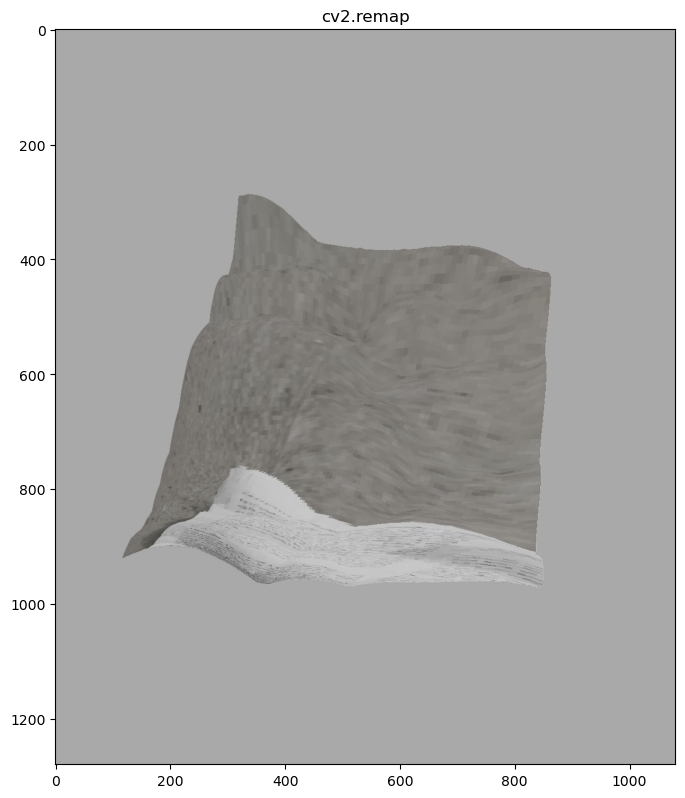

In [36]:
map_x = (u * (out_w - 1)).astype(np.float32)
map_y = (v * (out_h - 1)).astype(np.float32)

result = cv2.remap(rgb, map_x, map_y, 
                   interpolation=cv2.INTER_LINEAR,
                   borderMode=cv2.BORDER_CONSTANT,
                   borderValue=(255,255,255))

plt.figure(figsize=(8,10))
plt.imshow(result)
plt.title('cv2.remap')
plt.show()

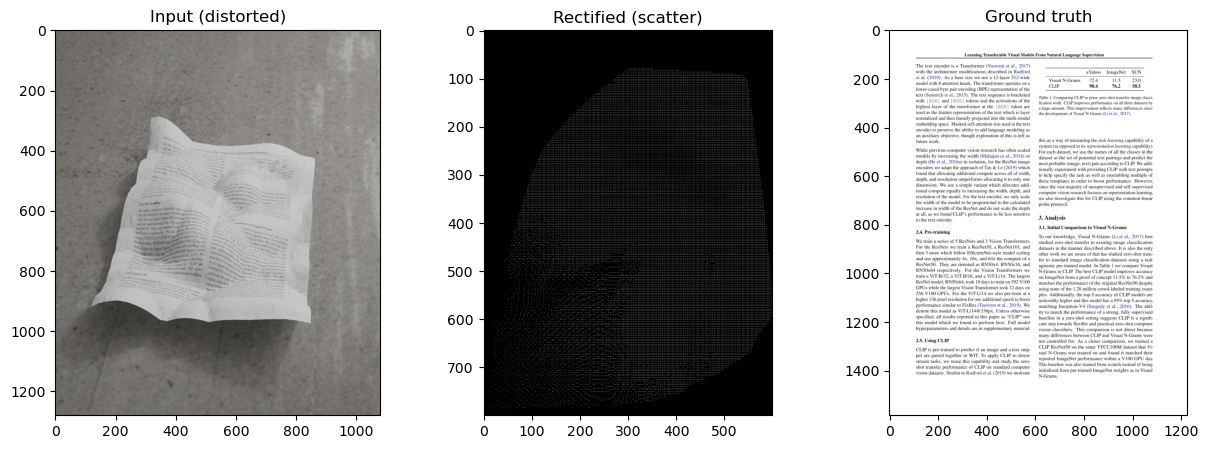

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title('Input (distorted)')
axes[1].imshow(output_uint8)
axes[1].set_title('Rectified (scatter)')
axes[2].imshow(np.array(Image.open(f'renders/synthetic_data_pitch_sweep/ground_truth/{filename}.png')))
axes[2].set_title('Ground truth')
plt.show()

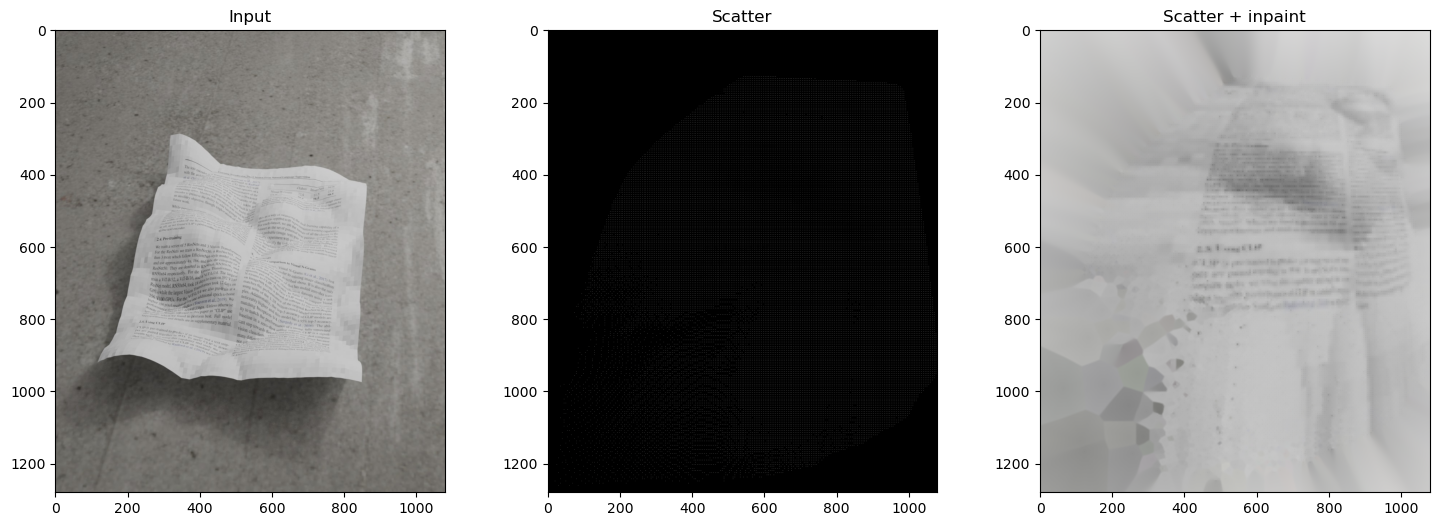

output max: 206
filled pixels: 23287 / 1382400


In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import os

filename = os.listdir('renders/synthetic_data_pitch_sweep/rgb')[0].replace('.jpg', '')

rgb = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/rgb/{filename}.jpg').convert('RGB'))
uv = np.array(Image.open(f'renders/synthetic_data_pitch_sweep/uv/{filename}.png').convert('RGB'))

out_h, out_w = rgb.shape[0], rgb.shape[1]

bg = np.array([124, 124, 124])
diff = np.abs(uv.astype(int) - bg).max(axis=2)
doc_mask = diff > 30

u = uv[:,:,0].astype(np.float32) / 219.0
v = 1.0 - uv[:,:,1].astype(np.float32) / 219.0

out_x = (u * (out_w - 1)).astype(int).clip(0, out_w-1)
out_y = (v * (out_h - 1)).astype(int).clip(0, out_h-1)

output = np.zeros((out_h, out_w, 3), dtype=np.float32)
counts = np.zeros((out_h, out_w), dtype=np.float32)

np.add.at(output, (out_y[doc_mask], out_x[doc_mask]), rgb[doc_mask].astype(np.float32) / 255.0)
np.add.at(counts, (out_y[doc_mask], out_x[doc_mask]), 1)

counts = np.maximum(counts, 1)
output = output / counts[:,:,None]

output_uint8 = (output * 255).astype(np.uint8)
hole_mask = (counts == 1).astype(np.uint8) * 255
result = cv2.inpaint(output_uint8, hole_mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(rgb)
axes[0].set_title('Input')
axes[1].imshow(output_uint8)
axes[1].set_title('Scatter')
axes[2].imshow(result)
axes[2].set_title('Scatter + inpaint')
plt.show()

print(f"output max: {output_uint8.max()}")
print(f"filled pixels: {(counts>1).sum()} / {out_h*out_w}")

In [3]:
import cv2
import numpy as np
from scipy.interpolate import griddata

# 1. Load images
# img = cv2.imread('warped_photo.jpg')
# uv = cv2.imread('uv_map.png').astype(np.float32) / 255.0

# 2. Define the output resolution (The "Flat" paper size)
out_h, out_w = 1000, 800

# 3. Create a mask to ignore the gray background
# Assuming gray is (127, 127, 127) or similar
mask = np.sum(uv, axis=2) > 0.1 # Adjust threshold to isolate the document
warped_coords = np.argwhere(mask) # (y, x) in the crumpled photo

# 4. Extract target coordinates from the UV map
# UV channels: Red = X, Green = Y (Standard convention)
target_x = uv[mask, 2] * (out_w - 1)
target_y = uv[mask, 1] * (out_h - 1)

# 5. Get the pixel colors from the original photo
pixel_values = rgb[mask]

# 6. Interpolate (Splat) the pixels onto the flat grid
grid_x, grid_y = np.mgrid[0:out_h, 0:out_w]
rectified = griddata((target_y, target_x), pixel_values, (grid_y, grid_x), method='linear')

# Convert back to uint8 for viewing
rectified = np.clip(rectified, 0, 255).astype(np.uint8)

cv2.imshow('Rectified Document', rectified)
cv2.waitKey(0)

/var/folders/5_/vbtrmswx10l_llx4zkn2tkf40000gn/T/ipykernel_89582/1271244485.py:30: RuntimeWarning: invalid value encountered in cast
  rectified = np.clip(rectified, 0, 255).astype(np.uint8)


-1